# Практическое ДЗ 1. Удаление фона с помощью SVD

В этой задаче мы познакомимся с одним из возможных приложений сингулярного разложения &mdash; удаление фона из видео.
Для этого сначала загрузим видео, на котором есть движущиеся объекты и неизменный фон.


**Замечание: далее пользоваться циклами запрещено, если это явно не прописано в задании. Вместо этого используйте функции numpy.**

In [1]:
%pip install -q moviepy==1.0.3
%pip install -q ffmpeg

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [42]:
import numpy as np

custom_style = {
    'axes.facecolor': '#1E1E2F',
    'axes.edgecolor': '#FFFFFF',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#FFFFFF',
    'ytick.color': '#FFFFFF',
    'text.color': '#FFFFFF',
    'figure.facecolor': '#1E1E2F',
    'grid.color': '#4A4A6A',
    'lines.linewidth': 2,
    'lines.color': '#FF6F61',
    'patch.edgecolor': '#FFFFFF',
    'boxplot.boxprops.color': '#FF6F61',
    'boxplot.whiskerprops.color': '#FF6F61',
    'boxplot.capprops.color': '#FF6F61',
    'boxplot.medianprops.color': '#00B4D8',
    'scatter.edgecolors': '#FF6F61'
}

plt.style.use(custom_style)

In [2]:
import moviepy.editor as mpe
video = mpe.VideoFileClip("data/SVD_video_1.mp4")
video.ipython_display(width=300, maxduration=250)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


Импортируем необходимые библиотеки и представим видео в виде трехмерного массива размеров `(#кадров) x (#пикселей по горизонтали) x (#пикселей по вертикали)`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
video.fps

23.976023976023978

In [5]:
video.duration

120.27

In [6]:
video.size

[80, 60]

In [7]:
def video_to_array(video):
    duration = int(video.duration)
    nframes = int(video.fps * video.duration)
    size_w, size_h = video.size
    arr = np.zeros([nframes, size_h, size_w])
    for i in range(nframes):
        arr[i, :, :] = video.get_frame(i/nframes * duration)[:, :, 0].astype(float)
    print('image size: {1:} x {2:}, \nnumber of frames: {0:}'.format(nframes, size_w, size_h))
    return arr

image size: 80 x 60, 
number of frames: 2883


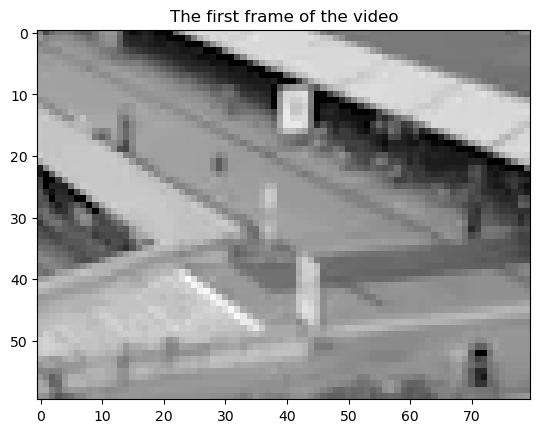

In [8]:
arr = video_to_array(video)
plt.imshow(arr[0, :, :], cmap='gray')
plt.title('The first frame of the video');

### a. Применение базового алгоритма SVD (30 баллов)

1. **(10 балла)** С помощью функции ```np.reshape(...)``` получите из трехмерного массива ```arr``` двумерный массив ```M``` размера ```(size_h * size_w) x nframes```, каждым столбцом которого является изображение размера ```size_h x size_w```, представленное в виде вектора с ```size_h * size_w``` элементами.

In [17]:
arr.shape

(2883, 60, 80)

In [21]:
arr.transpose(1, 2, 0).reshape(-1, nframes).shape

(4800, 2883)

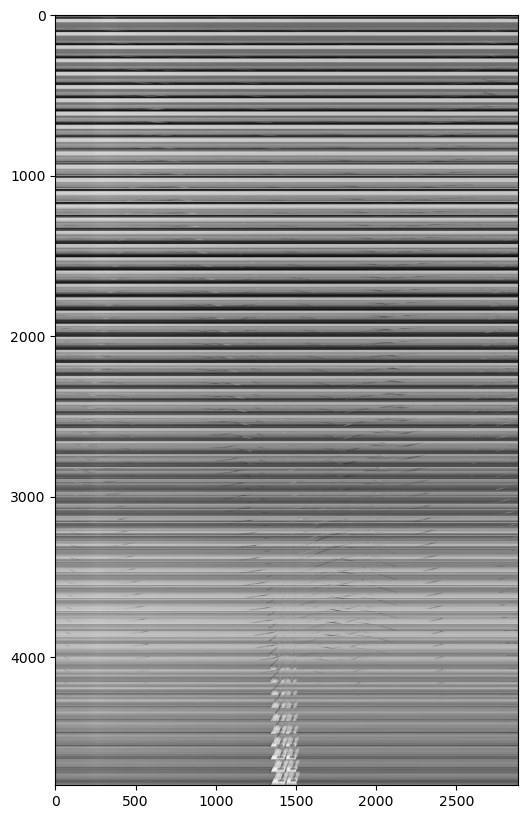

In [25]:
nframes, size_w, size_h = arr.shape
M = arr.transpose(1, 2, 0).reshape(-1, nframes)

plt.figure(figsize=(10, 10))
plt.imshow(M, cmap='gray');

Если всё сделано правильно, то вы сможете восстановить первый кадр из первого столбца:

In [31]:
# первый кадр 
arr[0]

array([[117.,  66.,  95., ..., 103., 116., 122.],
       [135., 115., 124., ..., 104., 103., 102.],
       [115., 124., 133., ..., 105., 105., 107.],
       ...,
       [149., 138.,  90., ..., 123., 119., 117.],
       [150., 150., 116., ..., 112., 111., 110.],
       [132., 129., 104., ..., 128., 132., 135.]])

In [33]:
M.shape

(4800, 2883)

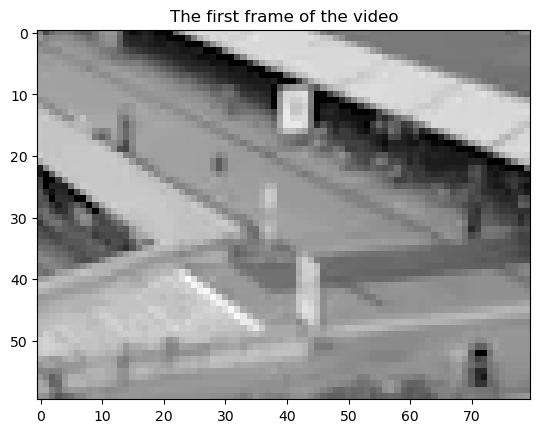

In [34]:
first_frame = M[:, 0].reshape(60, 80)
plt.imshow(first_frame, cmap='gray')
plt.title('The first frame of the video');

2. **(6 баллов)** Вычислите сингулярное разложение матрицы ```M``` с помощью ```np.linalg.svd(..., full_matrices=False)``` (параметр ```full_matrices``` отвечает за размеры матрицы $U$ и $V$ из SVD и позволяет заметно экономить место для прямоугольных матриц). Постройте график сингулярных чисел, отсортированных по убыванию и поделенных на старшее сингулярное число. Шкала с сингулярными числами должна быть логарифмической. Для этого, например, используйте функцию ```plt.semilogy```. Объясните, почему наибольшее и несколько наименьших (близких к 0) сингулярных число заметно отличается от остальных.

**Замечание:** При построении графиков величин с отличающимися на порядки значениями полезно использовать логарифмическую шкалу. Чтобы убедиться в этом, попробуйте построить график не в логарифмической шкале; из него будет фактически невозможно понять характер убывания сингулярных чисел. Не забывайте подписывать оси!

In [35]:
U, s, V = np.linalg.svd(M, full_matrices=False)

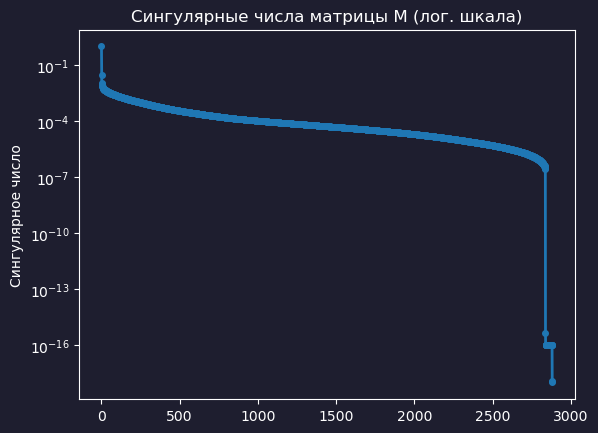

In [52]:
sing_val = np.sort(s)[::-1] / np.max(s)

plt.semilogy(sing_val, 'o-', markersize=4)
plt.title('Сингулярные числа матрицы М (лог. шкала)')
plt.ylabel('Сингулярное число');

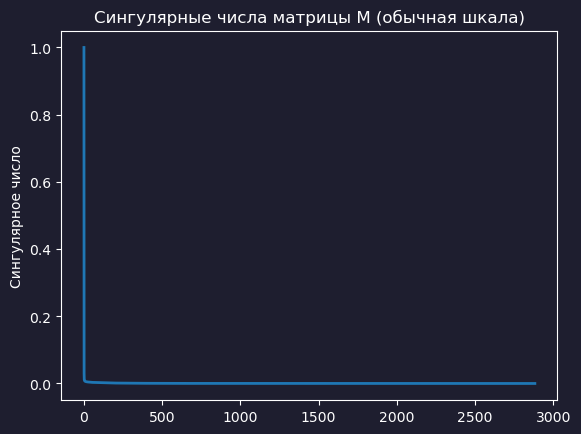

In [53]:
sing_val = np.sort(s)[::-1] / np.max(s)

plt.plot(sing_val)
plt.title('Сингулярные числа матрицы М (обычная шкала)')
plt.ylabel('Сингулярное число');

**Ответ:** Наибольшие сингулярные числа - отвечают за направления с наибольшей дисперсией в данных, соответсвенно в видео есть немного доминирующих сцен, которые отвечают за основное изменение (например, фон). В видео много статики - поэтому большинство сингулярных чисел более близки друг к другу. Наименьшие сингулярные числа - шум и мелкие детали, имеют наименьший вклад. 

3. **(10 баллов)** Напишите функцию ```trunc_svd(M, r)```, которая считает оптимальное приближение $M_{r}$ двумерного массива $M$ заданного ранга, а также **относительную** точность этого приближения в фробениусовой норме, т.е. $$
\frac{\|M - M_{r}\|_F}{\|M\|_F}.
$$
Для расчета относительной точности используйте **только** сингулярные числа матрицы $M$.

In [54]:
def trunc_svd(M, r):
    '''
        Input
            M: 2D numpy array
            r: rank value for truncation

        Output
            Mr: 2D numpy array of the same size as M
            rel_eps: relative error of rank-r approximation Mr
    '''
    U, s, V = np.linalg.svd(M, full_matrices=False)
    
    Ur = U[:, :r]
    sr = s[:r]
    Vr = V[:r, :]
    
    Mr = Ur @ np.diag(sr) @ Vr

    norm_M = np.linalg.norm(M, 'fro')
    error = np.linalg.norm(M - Mr, 'fro')
    rel_eps = error / norm_M
    
    return Mr, rel_eps

4. **(4 балла)** Используя написанную функцию, найдите наилучшее приближение матрицы ```M``` матрицей ```M_svd``` ранга 1. С помощью ```plt.imshow(..., cmap='gray')``` постройте изображения первого кадра
    - исходного видео
    - фона (полученного из приближения ранга 1)
    - изображения людей (полученного с помощью изображений из предыдущих двух подпунктов)

In [60]:
M_trunc.shape

(4800, 2883)

In [61]:
M_trunc, res_eps = trunc_svd(M, r=1)

first_frame = M[:, 0].reshape(60, 80)
background = M_trunc[:, 0].reshape(60, 80)

moving_objects = first_frame - background

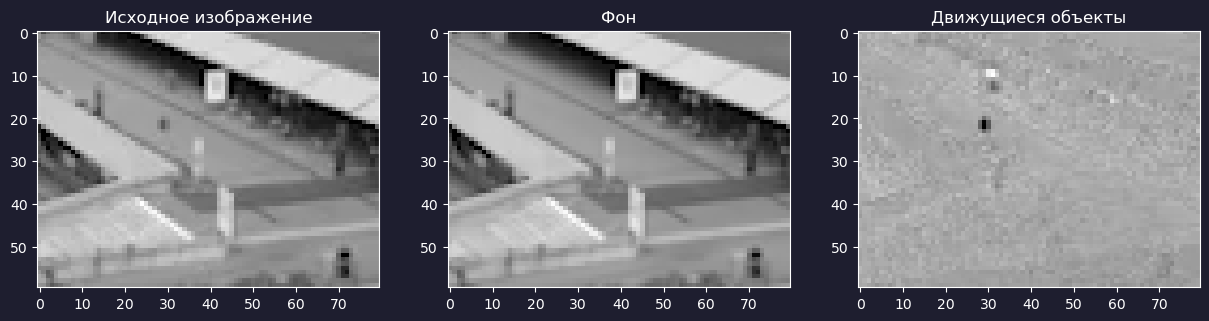

In [62]:
_, axs = plt.subplots(1,3, figsize=(15,10))
axs[0].imshow(first_frame, cmap='gray') # TO BE FILLED
axs[0].set_title("Исходное изображение")
axs[1].imshow(background, cmap='gray') # TO BE FILLED
axs[1].set_title("Фон")
axs[2].imshow(moving_objects, cmap='gray') # TO BE FILLED
axs[2].set_title("Движущиеся объекты");

### b. Применение рандомизированного алгоритма SVD (28 баллов)

Загрузим теперь видео в более высоком разрешении.

In [63]:
import moviepy.editor as mpe
video3 = mpe.VideoFileClip("data/SVD_video_3.mp4", target_resolution=(100, 178))
video3.ipython_display(width=300, maxduration=250)
arr = video_to_array(video3)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4
image size: 178 x 100, 
number of frames: 3600


In [64]:
arr3 = video_to_array(video3)
nframes, size_w, size_h = arr3.shape
M3 = arr3.transpose(1, 2, 0).reshape(-1, nframes)

image size: 178 x 100, 
number of frames: 3600


Использование функции ```np.linalg.svd``` является эффективным для относительно небольших массивов из-за быстрого роста сложности алгоритма в зависимости от размера матрицы. Используем рандомизированный алгоритм из лекций для ускорения вычислений (есть также [пост](https://gregorygundersen.com/blog/2019/01/17/randomized-svd/) с описанием алгоритма).

1. **(16 баллов)** Реализуйте рандомизированный алгоритм SVD из лекций, который аппроксимирует матрицу с заданным рангом $r$ (алгоритм запускается с ```r + oversampling``` случайных векторов, после чего ранг обрезается до ```r``` с наименьшей ошибкой). Убедитесь, что вы не вычисляете в явном виде матрицу $QQ^\top$. Если на заданной матрице алгоритм работает слишком долго (минуты), то возможно, вы что-то делаете не так.

In [74]:
def rand_svd(M, r, oversampling=10):
    '''
        Input
            M: 2D numpy array
            r: rank value for truncation
            oversampling: number of extra random vectors to approximate range(M)

        Output
            Mr: 2D numpy array of rank r and of the same size as M
            rel_eps: relative error of rank-r approximation Mr
    '''
    m, n = M.shape
    l = r + oversampling

    omega = np.random.randn(n, l)

    Y = M @ omega

    Q, R = np.linalg.qr(Y)

    B = Q.T @ M

    U, s, V = np.linalg.svd(B, full_matrices=False)

    Ur = U[:, :r]
    sr = s[:r]
    Vr = V[:r, :]

    Ur = Q @ Ur

    Mr = Ur @ np.diag(sr) @ Vr

    norm_M = np.linalg.norm(M, 'fro')
    error = np.linalg.norm(M - Mr, 'fro')
    rel_eps = error / norm_M
    
    return Mr, rel_eps

2. **(2 балл)** Используя ```rand_svd```, найдите наилучшее приближение матрицы ```M``` матрицей ```M_rand``` ранга 1. С помощью ```plt.imshow(..., cmap='gray')``` постройте изображения первого кадра
    - исходного видео
    - фона (полученного из приближения ранга 1)
    - изображения людей (полученного с помощью изображений из предыдущих двух подпунктов)

In [75]:
M_trunc, res_eps = rand_svd(M, r=1)

original = M[:, 0].reshape(60, 80)
background = M_trunc[:, 0].reshape(60, 80)

moving_objects = first_frame - background

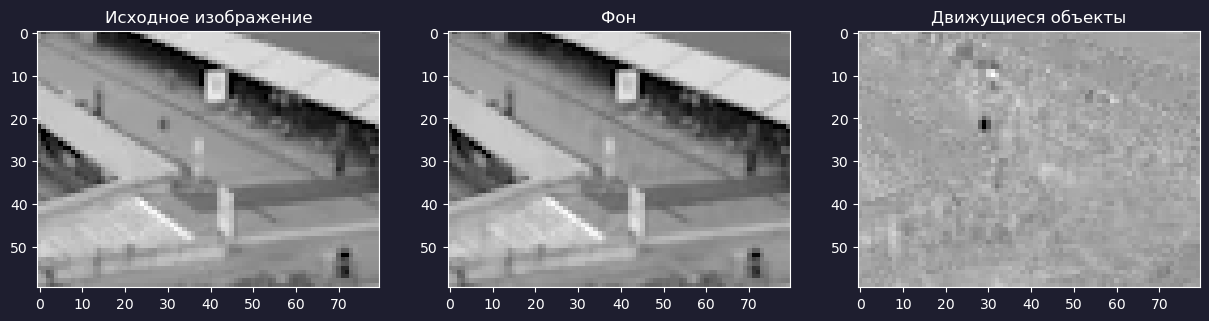

In [76]:
_, axs = plt.subplots(1,3, figsize=(15,10))
axs[0].imshow(original, cmap='gray') # TO BE FILLED
axs[0].set_title("Исходное изображение")
axs[1].imshow(background, cmap='gray') # TO BE FILLED
axs[1].set_title("Фон")
axs[2].imshow(moving_objects, cmap='gray') # TO BE FILLED
axs[2].set_title("Движущиеся объекты");

3. **(10 баллов)** Постройте график функции
$$
\frac{||M_{rand}(p) - M||_F}{||M||_F}
$$
при $r=2$ в зависимости от $p$ (```oversampling=p``` в функции ```rand_svd```). По $p$ выберите сетку $[0, 30]$ с шагом 2.
Так как $M_{rand}(p)$ получено с помощью рандомизированного алгоритма, усредните Ваш результат, запустив алгоритм 10 раз.
При построении графика используйте логарифмическую шкалу по оси с ошибкой.
**В данном задании разрешается использовать циклы для перебора по сетке и запуска алгоритма 10 раз.**

In [77]:
np.random.seed(42) 

r = 2
ps = np.arange(0, 32, 2)
num_trials = 10

errors = []

for p in ps:
    trial_errors = []
    for _ in range(num_trials):
        Mr, rel_eps = rand_svd(M, r, oversampling=p)
        trial_errors.append(rel_eps)
    
    # Усредняем ошибку по 10 запускам
    errors.append(np.mean(trial_errors))

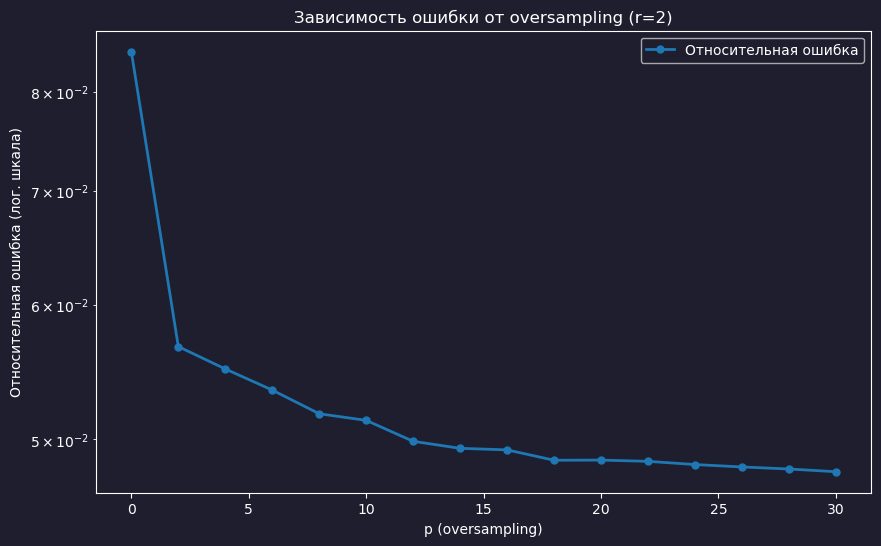

In [79]:
plt.figure(figsize=(10, 6))
plt.semilogy(ps, errors, 'o-', markersize=5, label='Относительная ошибка')
plt.xlabel('p (oversampling)')
plt.ylabel('Относительная ошибка (лог. шкала)')
plt.title('Зависимость ошибки от oversampling (r=2)')
plt.legend()
plt.show()

**Замечание:** ```np.linalg.svd``` на этих размерах матриц и значенях рангов будет работать заметно медленнее (правда, с полностью контролируемой точностью), чем рандомизированный алгоритм. Также обратите внимание, что если не указать опцию ```full_matrices=False``` в ```np.linalg.svd```, то на данном примере может случиться переполнение по памяти.

### c. Видео с переменным освещением (12 баллов)

Загрузим теперь более интересное видео, в котором со временем меняется освещение (можно, к примеру, представить, что встаёт солнце).

In [80]:
video2 = mpe.VideoFileClip("data/SVD_video_2.mp4")
video2.ipython_display(width=300, maxduration=250)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [81]:
arr2 = video_to_array(video2)

image size: 80 x 60, 
number of frames: 2883


Пока что возьмём лишь первые 80% видео, остальной частью воспользуемся позже.

In [83]:
breakpoint = round(0.8 * arr2.shape[0])
remaining = arr2[breakpoint:]
arr2 = arr2[:breakpoint]

1. Аналогично пункту a.1) получите из трехмерного массива ```arr2``` двумерный массив ```M2``` размера ```(size_h * size_w) x nframes2```.

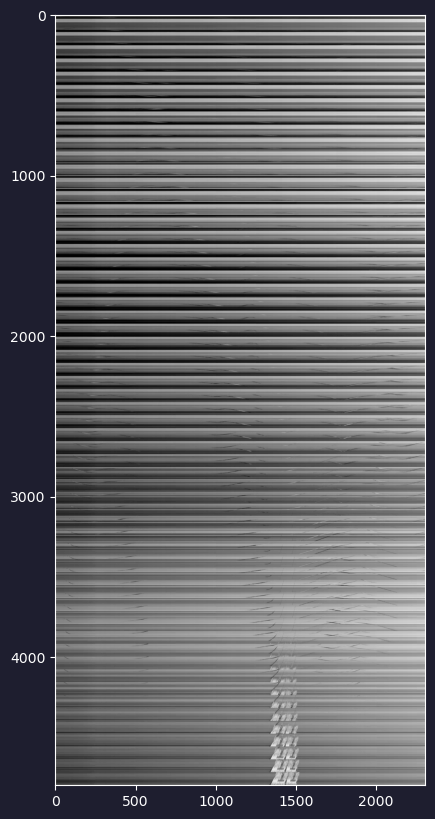

In [86]:
nframes2, size_w, size_h = arr2.shape
M2 = arr2.transpose(1, 2, 0).reshape(-1, nframes2)

plt.figure(figsize=(10, 10))
plt.imshow(M2, cmap='gray');

2. **(3 балла)** Примените методы из пунктов a) и b) (то есть библиотечное полное SVD и рандомизированное SVD) для получения наилучшего приближения ранга 2 (чтобы также учесть изменение освещения) для матрицы `M2`. Сравните время работы алгоритмов.

In [88]:
import time

In [125]:
def full_svd(M, r):
    U, s, V = np.linalg.svd(M, full_matrices=False)
    Mr = U[:, :r] @ np.diag(s[:r]) @ V[:r,:]
    return Mr

In [126]:
# Пременное освещение
start_time = time.time()
M2_svd = full_svd(M2, r=2)
end_time = time.time()
time_full_svd_2 = end_time - start_time

start_time = time.time()
M2_rand = rand_svd(M2, r=2)[0]
end_time = time.time()
time_rand_svd_2 = end_time - start_time



# Постоянное освещение
start_time = time.time()
M_svd = full_svd(M, r=2)
end_time = time.time()
time_full_svd = end_time - start_time

start_time = time.time()
M_rand = rand_svd(M, r=2)[0]
end_time = time.time()
time_rand_svd = end_time - start_time

In [127]:
print('----- Переменное освещение -----')
print(f'Время, затраченное на полное SVD: {time_full_svd_2}')
print(f'Время, затраченное на рандомизированное SVD: {time_rand_svd_2}')

print('----- Постоянное освещение -----')
print(f'Время, затраченное на полное SVD: {time_full_svd}')
print(f'Время, затраченное на рандомизированное SVD: {time_rand_svd}')

----- Переменное освещение -----
Время, затраченное на полное SVD: 7.753971099853516
Время, затраченное на рандомизированное SVD: 0.18801093101501465
----- Постоянное освещение -----
Время, затраченное на полное SVD: 15.026965141296387
Время, затраченное на рандомизированное SVD: 0.36999964714050293


**Вывод:** Рандомизированный SVD требует меньше времени, чем полный

3. **(4 балла)** Cравните относительные точности таких приближений для настоящего SVD и рандомизированного алгоритма; также сравните их с соответствующей величиной для видео с постоянным освещением. Какие выводы можно сделать?

In [128]:
norm_M2_rand = np.linalg.norm(M2, 'fro')
error_rand_2 = np.linalg.norm(M2 - M2_rand, 'fro')
rel_eps_rand_2 = error_rand_2 / norm_M2_rand

In [129]:
norm_M2_full = np.linalg.norm(M2, 'fro')
error_full_2 = np.linalg.norm(M2 - M2_svd, 'fro')
rel_eps_full_2 = error_full_2 / norm_M2_full

In [130]:
norm_M_rand = np.linalg.norm(M, 'fro')
error_rand = np.linalg.norm(M - M_rand, 'fro')
rel_eps_rand = error_rand / norm_M_rand

In [131]:
norm_M_full = np.linalg.norm(M, 'fro')
error_full = np.linalg.norm(M - M_svd, 'fro')
rel_eps_full = error_full / norm_M_full

In [132]:
print('----- Постоянное освещение -----')
print(f'Относительная ошибка полоного SVD: {rel_eps_full_2}')
print(f'Относительная ошибка рандомизированного SVD: {rel_eps_rand_2}')

print('----- Переменное освещение -----')
print(f'Относительная ошибка полоного SVD: {rel_eps_full}')
print(f'Относительная ошибка рандомизированного SVD: {rel_eps_rand}')

----- Постоянное освещение -----
Относительная ошибка полоного SVD: 0.0606323309845048
Относительная ошибка рандомизированного SVD: 0.06607529700291212
----- Переменное освещение -----
Относительная ошибка полоного SVD: 0.046855311565530786
Относительная ошибка рандомизированного SVD: 0.049230970063176


4. **(5 балла)** Заполните пропуски в функции `M_to_video`, преобразующей матрицу типа ```M2``` обратно в видео.

In [138]:
def M_to_video(M, fps, size_w, size_h):
    nframes = M.shape[1]
    arr = M.reshape(size_w, size_h, nframes).transpose(2, 0, 1)
    def make_frame(t):
        index = int(t * fps)
        frame = arr[index, :, :]
        frame = np.clip(frame, 0, 255)
        frame_rgb = frame[:, :, np.newaxis][:, :, [0,0,0]]
        return frame_rgb
    return mpe.VideoClip(make_frame, duration=nframes / fps)

Посмотрим, как выглядит предлагаемое приближение.

In [145]:
# Ура! люди двигаются
video2_svd = M_to_video(M2_svd - M2, 20, size_w, size_h)
video2_svd.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


Для большей наглядности можете также запустить видео из пункта b) с более высоким разрешением.

### d. Обработка новых кадров (25 баллов)

Предположим, что на камеру поступил новый поток кадров. Мы могли бы увеличить нашу матрицу M2 и пересчитать SVD, но это слишком вычислительно сложно ради нескольких новых кадров. Более того, логично предположить, что если у нас уже было достаточно много кадров в матрице M2, то сингулярные векторы не изменятся сильно от добавления новых кадров.

При этом просто вычесть фон не получится, ведь мы хотим также учитывать изменение освещения. Для этого посчитаем ортогональную проекцию нового кадра на образ матрицы M2.




1. **(15 баллов)** Используя SVD разложение ортогонально спроецируйте новый кадр на образ матрицы M2.

Ваш код должен работать как для 1 кадра (вектора длины size_h * size_w), так и для нескольких (матрицы размера (size_h * size_w) x k). Сложность итогового алгоритма для обработки 1 кадра должна быть O(size_h * size_w). SVD матрицы M2 считайте предпосчитанным.

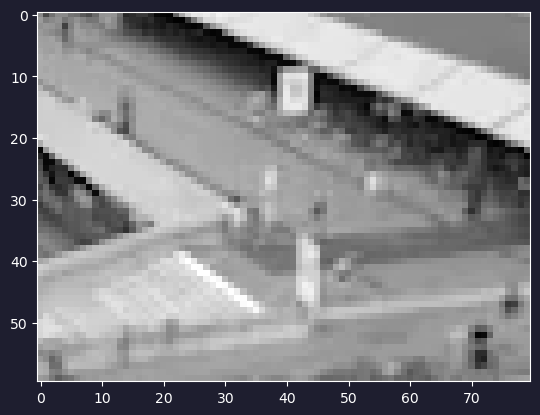

In [146]:
new_frame = remaining[-1].reshape(size_w*size_h)
plt.imshow(new_frame.reshape(size_w, size_h), cmap='gray');

In [174]:
remaining[-2:].transpose(1, 2, 0).reshape(-1, remaining[-2:].shape[0])

array([[157., 157.],
       [105., 105.],
       [137., 137.],
       ...,
       [168., 168.],
       [172., 172.],
       [174., 174.]])

In [175]:
remaining[-1].reshape(size_w * size_h).reshape(-1, 1)

array([[157.],
       [105.],
       [137.],
       ...,
       [168.],
       [172.],
       [174.]])

In [209]:
# YOUR CODE GOES HERE (duplicate code from trunc_SVD)
U, s, V = np.linalg.svd(M2, full_matrices=False)
    
U_2 = U[:, :2]
S_2 = s[:2]
VT_2 = V[:2, :]

In [210]:
def project_new_frames(U, S, VT, new_frames):
    '''
        Input
            U, S, VT: rank r compact SVD of matrix M2 (U @ S @ VT = M2_r)
            new_frames:  vector (size_h * size_w,) or matrix (size_h * size_w x nframes)

        Output
            proj: projection of new frames to Im(M2_r)
    '''
    if new_frames.ndim == 1:
        new_frames = new_frames.reshape(-1, 1)

    proj = U @ (U.T @ new_frames)
    
    return proj.squeeze()

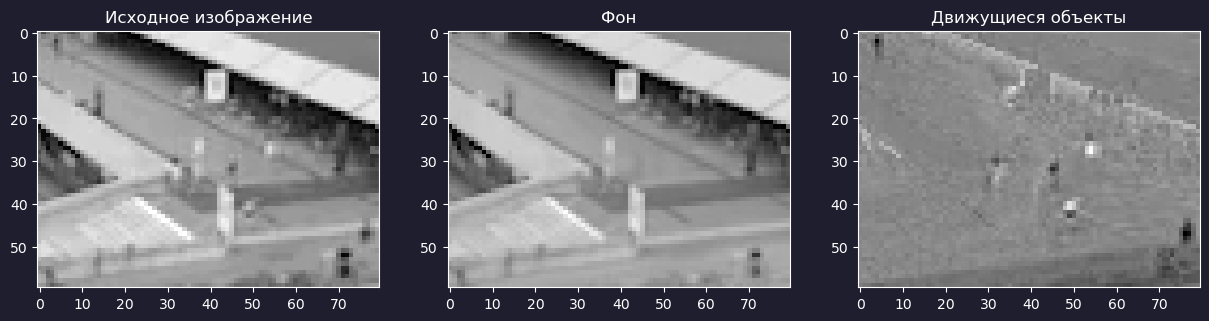

In [211]:
new_frame_proj = project_new_frames(U_2, S_2, VT_2, new_frame)

background = new_frame_proj.reshape(size_w, size_h)
moving_objects = new_frame.reshape(size_w, size_h) - background

_, axs = plt.subplots(1,3, figsize=(15,10))
axs[0].imshow(new_frame.reshape(size_w, size_h), cmap='gray')
axs[0].set_title("Исходное изображение")
axs[1].imshow(background, cmap='gray') # TO BE FILLED
axs[1].set_title("Фон")
axs[2].imshow(moving_objects, cmap='gray') # TO BE FILLED
axs[2].set_title("Движущиеся объекты");

2. **(5 баллов)** Используя [np.concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html) добавьте кадры из remaining к столбцам M2, чтобы получить матрицу полного видео M_full. Аналогично преобразуйте трехмерный массив remaining в матрицу формате (size_h * size_w x remaining_nframes). Спроецируйте все кадры (столбцы) этой матрицы и преобразуйте матрицу обратно в видео.


In [187]:
remaining_nframes, size_w, size_h = remaining.shape
M_remaining = remaining.transpose(1, 2, 0).reshape(-1, remaining.shape[0])
M_full = np.concatenate([M2, M_remaining], axis=1)

In [189]:
M_full.shape

(4800, 2883)

In [190]:
M_proj = project_new_frames(U_2, S_2, VT_2, M_full)

video2_svd = M_to_video(M_full - M_proj, 20, size_w, size_h)
video2_svd.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


3. **(2 балла)** Как говорилось выше, можно сэкономить много ресурсов с помощью рандомизированного SVD алгоритма. Рассмотрите аналогичную ортопроекцию с помощью рандомизированного SVD разложения.

In [219]:
r = 2
oversampling = 10

# скопируем код из функции

def rand_svd(M, r, oversampling=10):
    m, n = M.shape
    l = r + oversampling
    
    omega = np.random.randn(n, l)

    Y = M @ omega

    Q, R = np.linalg.qr(Y)

    B = Q.T @ M

    U, s, V = np.linalg.svd(B, full_matrices=False)

    Ur = U[:, :r]
    sr = s[:r]
    Vr = V[:r, :]

    Ur = Q @ Ur
    
    return Ur, sr, Vr

# YOUR CODE GOES HERE (duplicate code from rand_SVD)
U_2_rand, S_2_rand, VT_2_rand = rand_svd(M2, r, oversampling)

In [223]:
M_proj_rand = project_new_frames(U_2_rand, S_2_rand, VT_2_rand, M_full)

video2_svd = M_to_video(M_full - M_proj_rand, 20, size_w, size_h)
video2_svd.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


4. **(3 балла)** Найдите $M_{\text{true}}$ - лучшее приближение 2 ранга матрицы M2_full с помощью честного SVD (аналогично заданию c). Посчитайте относительные точности приближений из пунктов 2 и 3; сравните качество видео. Какие выводы можно сделать по качеству видео и итоговым ошибкам?

$$
    \dfrac{\| M_{\text{true}} - M_{\text{proj}} \|_F}{\| M_{\text{true}} \|_{F}};\quad
    \dfrac{\| M_{\text{true}} - M_{\text{proj rand}} \|_F}{\| M_{\text{true}} \|_{F}}
$$

In [228]:
M_true = trunc_svd(M_full, 2)[0]

video2_svd = M_to_video(M_full - M_true, 20, size_w, size_h)
video2_svd.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [229]:
video_proj_rand = M_to_video(M_full - M_proj_rand, 20, size_w, size_h)
video_proj_rand.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [237]:
def relative_error(true, approx):
    return np.linalg.norm(true - approx, 'fro') / np.linalg.norm(true, 'fro')

error_true = relative_error(M_full, M_true)
error_proj_rand = relative_error(M_full, M_proj_rand)

print("Относительная ошибка (полное SVD):", error_true)
print("Относительная ошибка (рандомизированное SVD):", error_proj_rand)

Относительная ошибка (точное SVD): 0.054595385055049184
Относительная ошибка (рандомизированное SVD): 0.0601552954128753


**Выводы:** Качество не слишком сильно различается, поэтому рандомизированный SVD может быть использован вместо полного, если незначительные ухужшения качества не так серьезны.

### e. Robust PCA (5 баллов)

Заметим, что матрицу $M$ можно приближенно представить в виде $M = L + S$, где $L$ - малоранговая матрица, а $S$ - разреженная (то есть содержащая большое количество нулей). Для поиска $L$ и $S$ мы могли бы попытаться решить задачу

$$
    \mathrm{rank}(L) + \alpha\ \mathrm{nnz}(S) \to \min_{L,S}, \quad \alpha > 0
$$

при ограничении $M = L + S$, где $\mathrm{nnz}(S)$ обозначет число ненулевых элементов (<b>n</b>umber of <b>n</b>on<b>z</b>eros).
Однако такую задачу решать крайне сложно из-за отсутствия непрерывности и выпуклости.
Поэтому обычно ее [заменяют на более простую](https://arxiv.org/pdf/0912.3599.pdf):

$$
    \|L\|_* + \alpha \|S\|_{\mathrm{sum}} \to \min_{L, S}, \quad \alpha > 0,
$$

где $\|\cdot\|_*$ обозначает ядерную норму матрицы, а $\|\cdot\|_{\mathrm{sum}}$ является суммой модулей всех элементов матрицы ($\ell_1$-норма).

Для вычисления robust PCA скачаем код по ссылке [https://github.com/dganguli/robust-pca](https://github.com/dganguli/robust-pca) и импортируем его:

In [234]:
# Если вы работаете на windows - скачивайте самостоятельно
#!wget https://raw.githubusercontent.com/dganguli/robust-pca/master/r_pca.py
import r_pca

Мы использовали класс ```R_pca``` и запустили функцию ```fit(max_iter=4000, iter_print=100)``` для нахождения матриц $L$ и $S$ по матрице $M$ из пункта a).

1. **(5 баллов)** С помощью ```plt.imshow(..., cmap='gray')``` постройте изображения первого кадра
    - исходного видео,
    - фона,
    - изображения людей.

Обратите внимание, что на исходных данных метод может работать довольно долго (вероятно, часы). Поэтому предлагается взять только четверть временного ряда, а также вырезать каждый второй кадр. Используйте видео с низким разрешением из пункта a).

iteration: 1, error: 10.068199117432677
iteration: 100, error: 0.7004423976775113
iteration: 200, error: 0.4263207995832649
iteration: 300, error: 0.28615543342324445
iteration: 400, error: 0.19763762992234502
iteration: 500, error: 0.1491945130604214
iteration: 600, error: 0.11977760984867764
iteration: 700, error: 0.10258379675934326
iteration: 800, error: 0.08740324618544844
iteration: 900, error: 0.07772202053792632
iteration: 1000, error: 0.06319242183876873
iteration: 1100, error: 0.05727756160979911
iteration: 1200, error: 0.04361963207336601
iteration: 1300, error: 0.04277918295917907
iteration: 1400, error: 0.028313363611830206
iteration: 1500, error: 0.028215592054504666
iteration: 1546, error: 0.017703452810265762


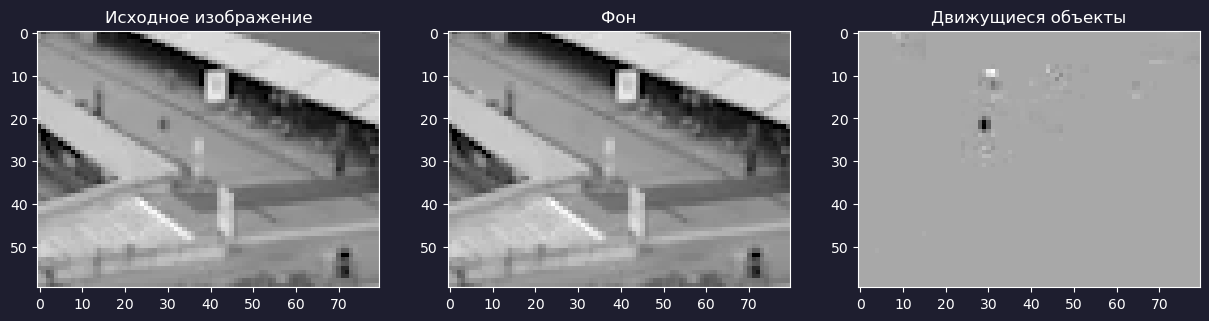

In [235]:
Mt = M[:,:M.shape[1]//4:2]
solver = r_pca.R_pca(Mt, mu=0.68) # в нашем случае такой mu работает лучше исходного
L, S = solver.fit(max_iter=4000, iter_print=100)

original = Mt[:, 0].reshape(size_w, size_h)
background = L[:, 0].reshape(size_w, size_h)
moving_objects = S[:, 0].reshape(size_w, size_h)

_, axs = plt.subplots(1, 3, figsize=(15, 10))
axs[0].imshow(original, cmap='gray')
axs[0].set_title("Исходное изображение")
axs[1].imshow(background, cmap='gray')
axs[1].set_title("Фон")
axs[2].imshow(moving_objects, cmap='gray')
axs[2].set_title("Движущиеся объекты")
plt.show()

Аналогично можно посмотреть на видео движущихся объектов:

In [236]:
video_rpca = M_to_video(S, 20, size_w, size_h) # TO BE FILLED
video_rpca.ipython_display(width=300, maxduration=250, fps=20)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


### f. Бонус

В бонусной части мы познакомимся с более продвинутыми рандомизированными алгоритмами поиска сингулярного разложения. Условие заданий базируется на статье

Halko, Nathan, Per-Gunnar Martinsson, and Joel A. Tropp. "Finding structure with randomness: Probabilistic algorithms for constructing approximate matrix decompositions." SIAM review 53.2 (2011): 217-288.

**Ссылка на статью**: http://users.cms.caltech.edu/~jtropp/papers/HMT11-Finding-Structure-SIREV.pdf

1. **(50 б. баллов)** Докажите, что в точной арифметике результат, полученный при использовании Алгоритма 4.3 и 4.4 из статьи, указанной выше, совпадают. Все теоретические выкладки приведите в текущем файле с использованием Markdown или прикрепите качественное изображение рукописного текста.

2. **(50 б. баллов)** Реализуйте Алгоритм 4.4 и используйте его для построения приближенного сингулярного разложения матрицы A на матрице из этой ДЗ. Зафиксируйте ранги $r=5, 20, 50$. Для каждого из этих значений на одном рисунке постройте график зависимости нормы (на выбор) разности полученного приближения и оптимального приближения (в выбранной норме) того же ранга от числа q.